In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
df = pd.read_csv('data/processed/online_retail_cleaned_final.csv')
df.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Year,Month,MonthName,Day,Weekday,Hour,YearMonth
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010,12,December,1,Wednesday,8,2010-12-01
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,December,1,Wednesday,8,2010-12-01
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010,12,December,1,Wednesday,8,2010-12-01
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,December,1,Wednesday,8,2010-12-01
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,December,1,Wednesday,8,2010-12-01
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850,United Kingdom,15.30,2010,12,December,1,Wednesday,8,2010-12-01
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850,United Kingdom,25.50,2010,12,December,1,Wednesday,8,2010-12-01
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850,United Kingdom,11.10,2010,12,December,1,Wednesday,8,2010-12-01
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850,United Kingdom,11.10,2010,12,December,1,Wednesday,8,2010-12-01
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047,United Kingdom,54.08,2010,12,December,1,Wednesday,8,2010-12-01


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 392732 entries, 0 to 392731
Data columns (total 16 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    392732 non-null  int64  
 1   StockCode    392732 non-null  str    
 2   Description  392732 non-null  str    
 3   Quantity     392732 non-null  int64  
 4   InvoiceDate  392732 non-null  str    
 5   UnitPrice    392732 non-null  float64
 6   CustomerID   392732 non-null  int64  
 7   Country      392732 non-null  str    
 8   Revenue      392732 non-null  float64
 9   Year         392732 non-null  int64  
 10  Month        392732 non-null  int64  
 11  MonthName    392732 non-null  str    
 12  Day          392732 non-null  int64  
 13  Weekday      392732 non-null  str    
 14  Hour         392732 non-null  int64  
 15  YearMonth    392732 non-null  str    
dtypes: float64(2), int64(7), str(7)
memory usage: 80.7 MB


In [4]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
Revenue        0
Year           0
Month          0
MonthName      0
Day            0
Weekday        0
Hour           0
YearMonth      0
dtype: int64

In [5]:
df.duplicated().sum()

0

In [6]:
df.describe()

,InvoiceNo,Quantity,UnitPrice,CustomerID,Revenue,Year,Month,Day,Hour
count,392732.000000,392732.000000,392732.000000,392732.000000,392732.000000,392732.000000,392732.000000,392732.000000,392732.000000
mean,560591.072436,13.153718,3.125596,15287.734822,22.629195,2010.934630,7.601935,15.044651,12.721579
std,13087.116747,181.588420,22.240725,1713.567773,311.083465,0.247178,3.415023,8.652557,2.276677
min,536365.000000,1.000000,0.000000,12346.000000,0.000000,2010.000000,1.000000,1.000000,6.000000
25%,549234.000000,2.000000,1.250000,13955.000000,4.950000,2011.000000,5.000000,7.000000,11.000000
50%,561874.000000,6.000000,1.950000,15150.000000,12.390000,2011.000000,8.000000,15.000000,13.000000
75%,572061.000000,12.000000,3.750000,16791.000000,19.800000,2011.000000,11.000000,22.000000,14.000000
max,581587.000000,80995.000000,8142.750000,18287.000000,168469.600000,2011.000000,12.000000,31.000000,20.000000


In [7]:
df['Description'].value_counts()

Description
WHITE HANGING HEART T-LIGHT HOLDER    2016
REGENCY CAKESTAND 3 TIER              1714
JUMBO BAG RED RETROSPOT               1615
ASSORTED COLOUR BIRD ORNAMENT         1395
PARTY BUNTING                         1390
                                      ... 
LETTER "T" BLING KEY RING                1
LETTER "U" BLING KEY RING                1
LETTER "W" BLING KEY RING                1
LETTER "Z" BLING KEY RING                1
PAPER CRAFT , LITTLE BIRDIE              1
Name: count, Length: 3877, dtype: int64

In [13]:
month_sales = df['Month'].value_counts().sort_index()
month_sales.describe()

count       12.000000
mean     32727.666667
std      13173.908706
min      19707.000000
25%      25545.250000
50%      26899.000000
75%      40428.000000
max      63182.000000
Name: count, dtype: float64

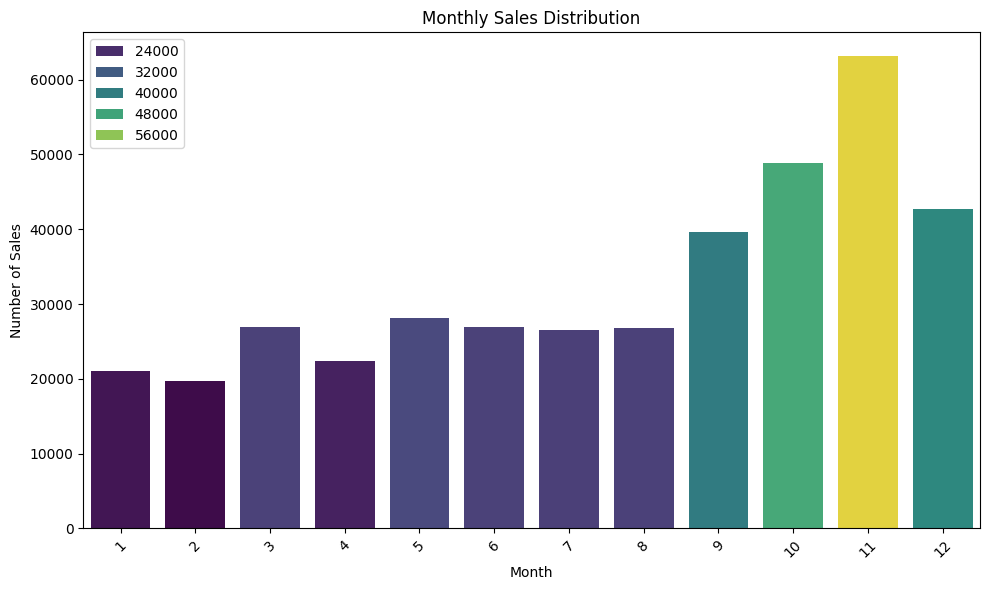

In [14]:
plt.figure(figsize=(10,6))
sns.barplot(x=month_sales.index, y=month_sales.values, palette='viridis', hue=month_sales.values)
plt.title('Monthly Sales Distribution')
plt.xlabel('Month')
plt.ylabel('Number of Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('reports/images/time_series_analysis/monthly_sales_distribution.png')
plt.show()

In [17]:
monthly_revenue = df.groupby('YearMonth')['Revenue'].sum().reset_index()

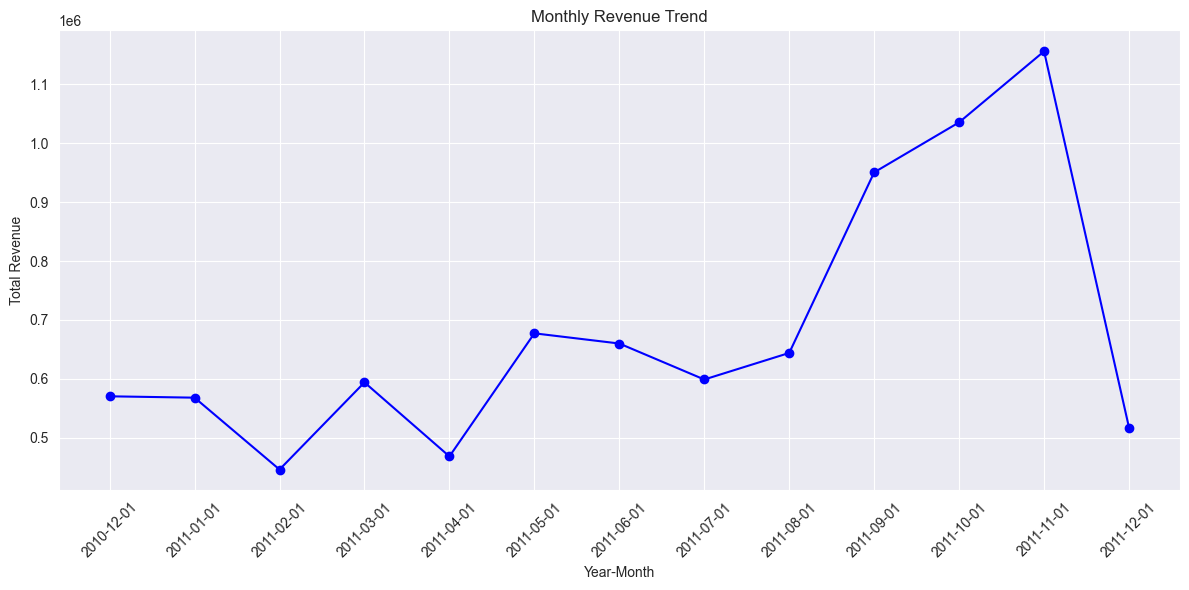

In [19]:
sns.set_style('darkgrid')

plt.figure(figsize=(12, 6))
plt.plot(monthly_revenue['YearMonth'], monthly_revenue['Revenue'], marker='o', linestyle='-', color='b')
plt.title('Monthly Revenue Trend')
plt.xlabel('Year-Month')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.savefig('reports/images/time_series_analysis/monthly_revenue_trend.png')
plt.show()

### 3. Ngày nào trong tuần có doanh thu cao nhất?

In [20]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'Revenue', 'Year', 'Month',
       'MonthName', 'Day', 'Weekday', 'Hour', 'YearMonth'],
      dtype='str')

In [21]:
day_values = df['Day'].value_counts().sort_index()
day_values.describe()

count       31.000000
mean     12668.774194
std       2414.970610
min       6722.000000
25%      11571.000000
50%      12792.000000
75%      14053.500000
max      18079.000000
Name: count, dtype: float64

In [32]:
day_values.max()
day_values.index[day_values.argmax()]

6

In [33]:
print(f"Maximum sales occur on day {day_values.index[day_values.argmax()]} with {day_values.max()} sales.")

Maximum sales occur on day 6 with 18079 sales.


In [34]:
print(f"Min sales occur on day {day_values.index[day_values.argmin()]} with {day_values.min()} sales.")

Min sales occur on day 31 with 6722 sales.


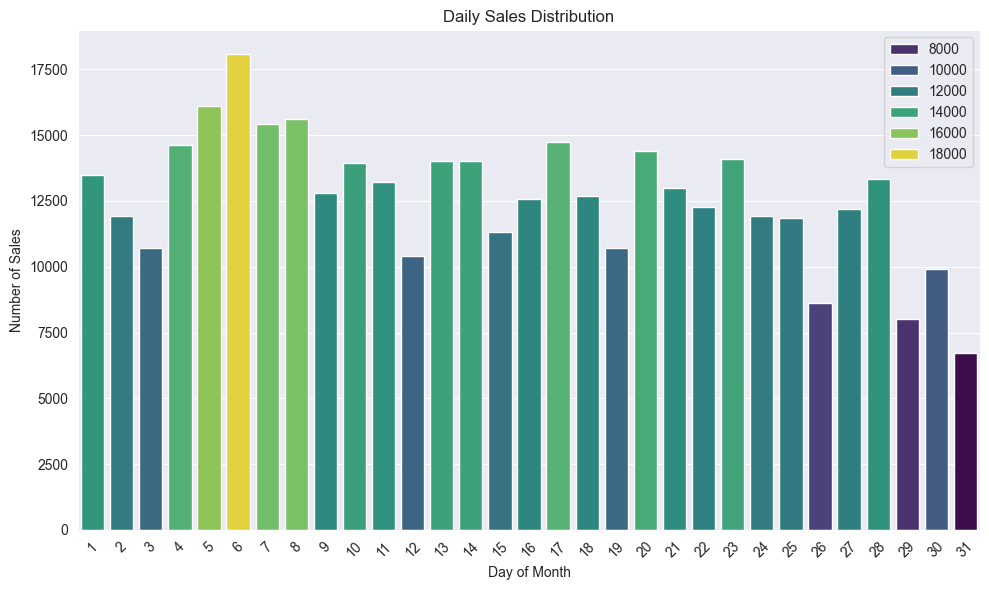

In [24]:
plt.figure(figsize=(10,6))
sns.barplot(x=day_values.index, y=day_values.values, palette='viridis', hue=day_values.values)
plt.title('Daily Sales Distribution')
plt.xlabel('Day of Month')
plt.ylabel('Number of Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('reports/images/time_series_analysis/daily_sales_distribution.png')
plt.show()

**Biểu đồ này đo lường tần suất giao dịch (số lượng đơn hàng) phát sinh vào các ngày từ 1 đến 31 trong tháng.**

* Đỉnh điểm giao dịch: Ngày 6 hàng tháng là ngày có số lượng đơn hàng cao nhất (vượt mức 17,500 đơn). Các ngày từ 4 đến 8 nhìn chung có lượng giao dịch rất sôi động.

* Chu kỳ giữa tháng: Lượng đơn hàng duy trì khá đều đặn từ ngày 13 đến ngày 23.

* Cuối tháng "nghỉ ngơi": Số lượng đơn hàng giảm mạnh rõ rệt từ ngày 26 đến 31. Đặc biệt ngày 31 có lượng giao dịch thấp nhất. 
Điều này có thể do tâm lý thắt chặt chi tiêu cuối tháng hoặc do các hệ thống chốt sổ.

In [25]:
day_revnue = df.groupby('Day')['Revenue'].sum().reset_index()

In [30]:
day_revnue.describe()

,Day,Revenue
count,31.000000,31.000000
mean,16.000000,286684.157871
std,9.092121,68140.759599
min,1.000000,149207.860000
25%,8.500000,248955.770000
50%,16.000000,285757.290000
75%,23.500000,333930.180000
max,31.000000,459306.140000


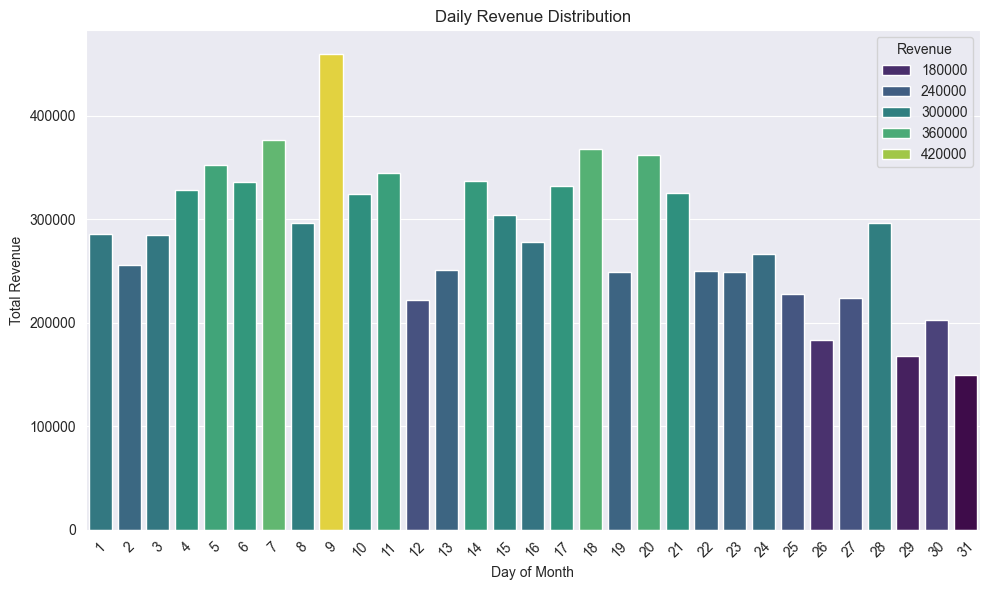

In [29]:
plt.figure(figsize=(10,6))
sns.barplot(x=day_revnue['Day'], y=day_revnue['Revenue'], palette='viridis', hue=day_revnue['Revenue'])
plt.title('Daily Revenue Distribution')
plt.xlabel('Day of Month')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('reports/images/time_series_analysis/daily_revenue_distribution.png')
plt.show()

In [35]:
day_9 = day_revnue[day_revnue['Day'] == 9]
print(f"Revenue on day 9: {day_9['Revenue'].values[0]}")

Revenue on day 9: 459306.14


***Sản phẩm (Cái gì), Khách hàng (Ai) và Thời gian (Tháng nào).***

In [36]:
df_day9 = df[df['Day'] == 9]
df_day9.describe()

,InvoiceNo,Quantity,UnitPrice,CustomerID,Revenue,Year,Month,Day,Hour
count,12792.000000,12792.000000,12792.000000,12792.000000,12792.000000,12792.000000,12792.000000,12792.0,12792.000000
mean,558024.298546,19.422608,3.021134,15312.720528,35.905733,2010.864056,7.869215,9.0,12.706066
std,14132.936422,717.284694,4.832107,1745.351178,1491.132684,0.342743,3.659691,0.0,2.396849
min,537879.000000,1.000000,0.040000,12347.000000,0.120000,2010.000000,1.000000,9.0,7.000000
25%,543543.000000,2.000000,1.250000,13856.000000,5.040000,2011.000000,5.000000,9.0,11.000000
50%,556248.000000,6.000000,1.950000,15296.000000,12.750000,2011.000000,9.000000,9.0,13.000000
75%,570231.000000,12.000000,3.750000,16833.000000,19.800000,2011.000000,11.000000,9.0,14.000000
max,581587.000000,80995.000000,208.340000,18274.000000,168469.600000,2011.000000,12.000000,9.0,20.000000


In [37]:
top_orders_day9 = df_day9.nlargest(10, 'Revenue')[['InvoiceNo', 'CustomerID', 'Description', 'Quantity', 'Revenue', 'YearMonth']]
print("Top 10 đơn hàng giá trị khủng nhất ngày 9:")
display(top_orders_day9)

Top 10 đơn hàng giá trị khủng nhất ngày 9:


,InvoiceNo,CustomerID,Description,Quantity,Revenue,YearMonth
392266,581483,16446,"PAPER CRAFT , LITTLE BIRDIE",80995,168469.60,2011-12-01
12682,537899,12755,ROUND SNACK BOXES SET OF 4 FRUITS,1488,3794.40,2010-12-01
13290,538063,18102,UTILTY CABINET WITH HOOKS,96,1914.24,2010-12-01
328800,575335,12931,ASSORTED COLOUR BIRD ORNAMENT,1200,1740.00,2011-11-01
327988,575213,16210,BLACK RECORD COVER FRAME,480,1627.20,2011-11-01
152673,556255,18102,DOORMAT UNION FLAG,300,1374.00,2011-06-01
152674,556255,18102,DOORMAT BLACK FLOCK,300,1374.00,2011-06-01
152675,556255,18102,DOORMAT WELCOME PUPPIES,300,1374.00,2011-06-01
152676,556255,18102,DOORMAT HOME SWEET HOME BLUE,300,1374.00,2011-06-01
152677,556255,18102,DOORMAT FANCY FONT HOME SWEET HOME,300,1374.00,2011-06-01


In [38]:
# Tổng hợp doanh thu theo từng sản phẩm trong ngày 9
top_products_day9 = df_day9.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10)
print("\nTop 10 sản phẩm hái ra tiền nhất ngày 9:")
print(top_products_day9)


Top 10 sản phẩm hái ra tiền nhất ngày 9:
Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
ROUND SNACK BOXES SET OF 4 FRUITS       4266.35
REGENCY CAKESTAND 3 TIER                3462.75
BLACK RECORD COVER FRAME                2761.02
ASSORTED COLOUR BIRD ORNAMENT           2606.97
WHITE HANGING HEART T-LIGHT HOLDER      2472.80
JUMBO BAG RED RETROSPOT                 2467.58
DOORMAT KEEP CALM AND COME IN           2189.85
POSTAGE                                 2131.00
PARTY BUNTING                           2118.85
Name: Revenue, dtype: float64


In [62]:
print(f"Products with highest revenue on day 9: {top_products_day9.index[0]} with revenue {top_products_day9.values[0]}")

Products with highest revenue on day 9: PAPER CRAFT , LITTLE BIRDIE with revenue 168469.6


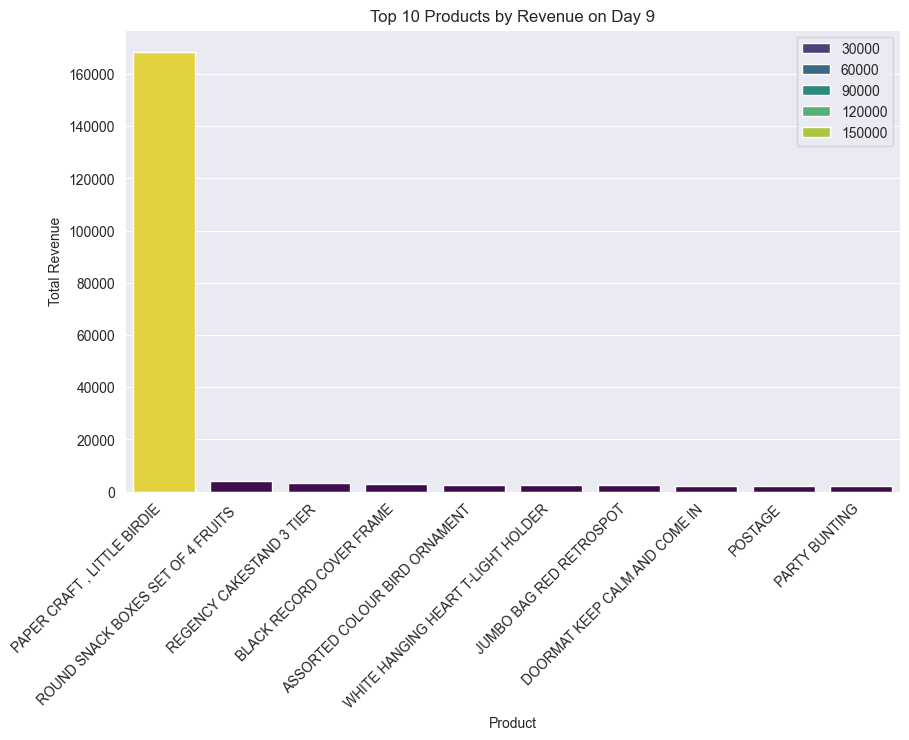

In [46]:
plt.figure(figsize=(10,6))
sns.barplot(x=top_products_day9.index, y=top_products_day9.values, palette='viridis', hue=top_products_day9.values)
plt.title('Top 10 Products by Revenue on Day 9')
plt.xlabel('Product')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45, ha='right')
plt.savefig('reports/images/time_series_analysis/top_products_day9.png')
plt.show()


In [39]:
top_customers_day9 = df_day9.groupby('CustomerID')['Revenue'].sum().sort_values(ascending=False).head(10)
print("\nTop 10 'Đại gia' mua sắm vào ngày 9:")
print(top_customers_day9)


Top 10 'Đại gia' mua sắm vào ngày 9:
CustomerID
16446    168469.60
18102     18871.68
14646     12498.71
17511      9565.54
12753      5735.24
12433      5246.80
12931      4961.20
17857      3975.20
12755      3794.40
13694      3027.31
Name: Revenue, dtype: float64


In [61]:
print(f"Customer with highest revenue on day 9: {top_customers_day9.index[0]} with revenue {top_customers_day9.values[0]}")

Customer with highest revenue on day 9: 16446 with revenue 168469.6


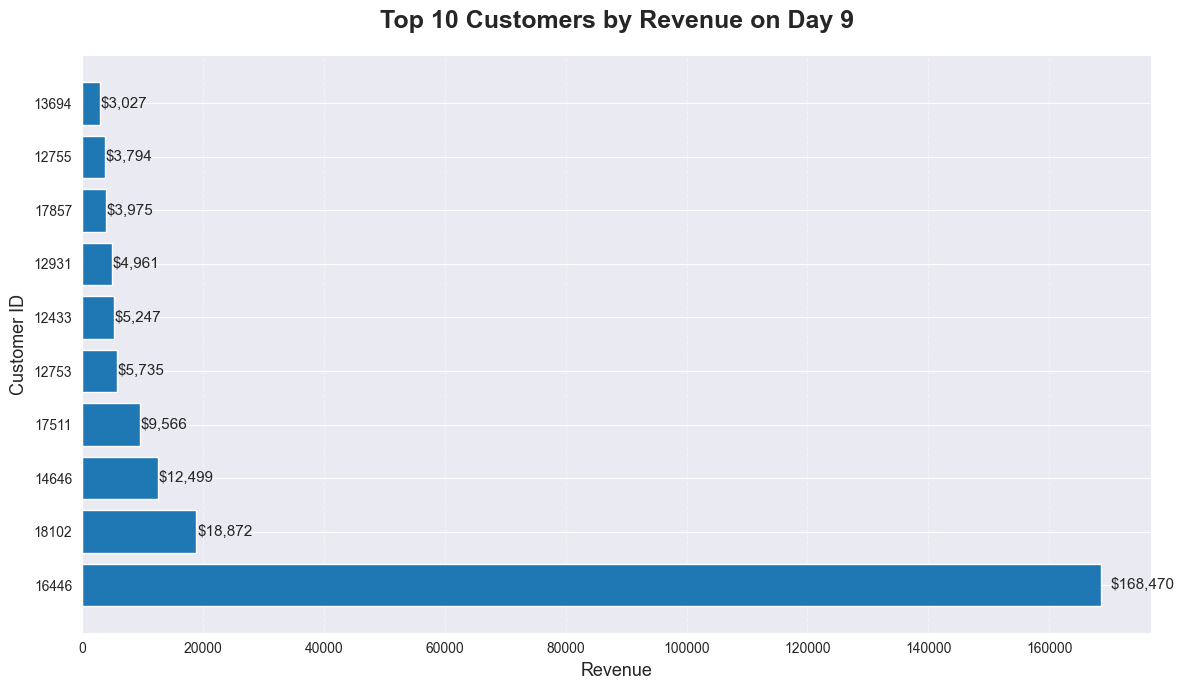

In [51]:
# Create figure
plt.figure(figsize=(12, 7))

# Create horizontal bar chart
bars = plt.barh(
    y=top_customers_day9.index.astype(str),
    width=top_customers_day9.values
)

# Title and labels
plt.title(
    'Top 10 Customers by Revenue on Day 9',
    fontsize=18,
    fontweight='bold',
    pad=20
)

plt.xlabel('Revenue', fontsize=13)
plt.ylabel('Customer ID', fontsize=13)

# Add revenue labels
for bar in bars:
    width = bar.get_width()
    
    plt.text(
        width + (width * 0.01),
        bar.get_y() + bar.get_height()/2,
        f'${width:,.0f}',
        va='center',
        fontsize=11
    )

# Remove top and right borders
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add grid
plt.grid(axis='x', linestyle='--', alpha=0.4)

# Improve layout
plt.tight_layout()
plt.savefig('reports/images/time_series_analysis/top_customers_day9.png')
# Show chart
plt.show()

In [40]:
monthly_day9_rev = df_day9.groupby('YearMonth')['Revenue'].sum().reset_index()
print("\nBiến động doanh thu ngày 9 qua các tháng:")
display(monthly_day9_rev)


Biến động doanh thu ngày 9 qua các tháng:


,YearMonth,Revenue
0,2010-12-01,38193.91
1,2011-01-01,15590.68
2,2011-02-01,11910.83
3,2011-03-01,20320.23
4,2011-05-01,21608.16
5,2011-06-01,42862.80
6,2011-08-01,25949.92
7,2011-09-01,25082.86
8,2011-10-01,12215.51
9,2011-11-01,61241.58


In [60]:
print(f"Maximum sales occur on day {day_values.index[day_values.argmax()]} with {day_values.max()} sales.")

Maximum sales occur on day 6 with 18079 sales.


In [54]:
monthly_day9_rev.describe()

,Revenue
count,11.000000
mean,41755.103636
std,49560.167457
min,11910.830000
25%,17955.455000
50%,25082.860000
75%,40528.355000
max,184329.660000


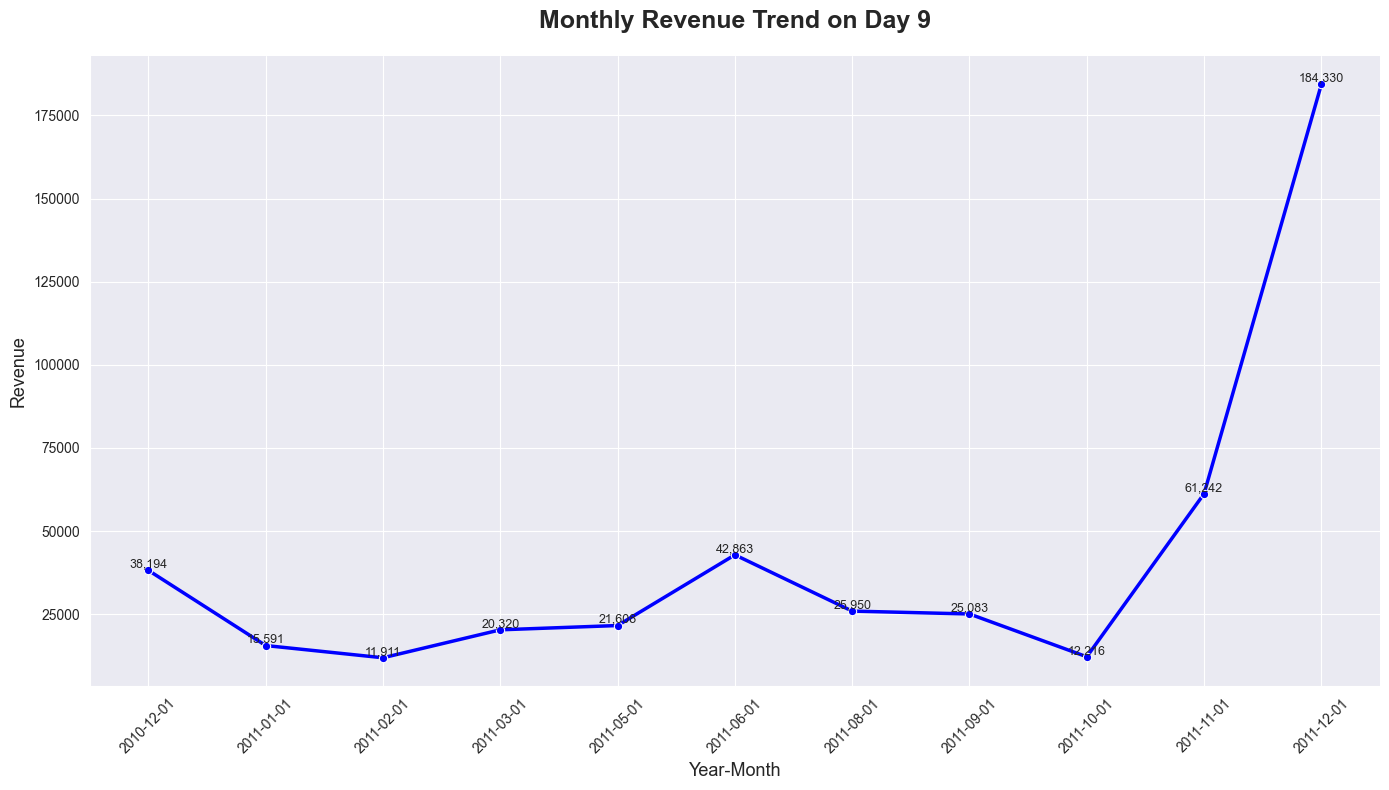

In [63]:
# Create figure
plt.figure(figsize=(14, 8))

# Seaborn lineplot
sns.lineplot(
    data=monthly_day9_rev,
    x='YearMonth',
    y='Revenue',
    marker='o',
    linewidth=2.5,
    color='b',
    linestyle='-',
)

# Title and labels
plt.title(
    'Monthly Revenue Trend on Day 9',
    fontsize=18,
    fontweight='bold',
    pad=20
)

plt.xlabel('Year-Month', fontsize=13)
plt.ylabel('Revenue', fontsize=13)

# Rotate x labels
plt.xticks(rotation=45)

# Add value labels
for i, value in enumerate(monthly_day9_rev['Revenue']):
    plt.text(
        i,
        value,
        f'{value:,.0f}',
        ha='center',
        va='bottom',
        fontsize=9
    )

# Remove unnecessary borders
sns.despine()

# Adjust layout
plt.tight_layout()
plt.savefig('reports/images/time_series_analysis/monthly_revenue_day9_trend.png')
# Show chart
plt.show()

**Vào ngày 09/12/2011, khách hàng ID 16446 đã mua một lượng khổng lồ sản phẩm "PAPER CRAFT, LITTLE BIRDIE", đóng góp hơn $168k vào hệ thống.**